# Agenda

- **Introduction** <br>
    - Format of this Workshop
    - Project Jupyter 
    - Accessing the JupyterLab Server <br><br>
- **Part 1: Data Management, Data Visualization & Data Science Basics** <br>
    - Clustering
    - Dimensionality Reduction <br><br>
- **Part 2: Data Science and Machine Learning** <br>
    - *Part 2.0* Neural Network Basics
        - Artificial Neural Networks
        - Activation functions
    - *Part 2.1:* NNs with Pytorch
        - Regression task with NNs
        - Classification with NNs
        - Convolutional NNs
    - *Part 2.2:* NNs with Tensorflow
        - Denoising with NNs<br><br>
- **Part 3: Framework comparison exercise** <br>
    - Data Preparation
    - Tensorboard
    - NN with Pytorch
    - NN with Tensorflow
<br><br>
- **References**


# Part 2 Data Science and Machine Learning

# Part 2.0 Neural Network Basics

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Neural Network: Introduction and Definitions

## Artificial Neural Networks

Artificial Neural Networks are a common tool used in Machine Learning. As the name suggests, they are modelled to emulate the functionality of biological neurons. They are composed of multiple layers of neurons, with functions connecting neurons of different layers with each other.

Depending on the input, the value of the neurons changes and thus affects the output. During the Training of these networks, the weights of the functions gets iteratively adjusted until the respective training inputs yield the desired outputs with an acceptable accuracy.

Schematic of an ANN's architecture:
<div>
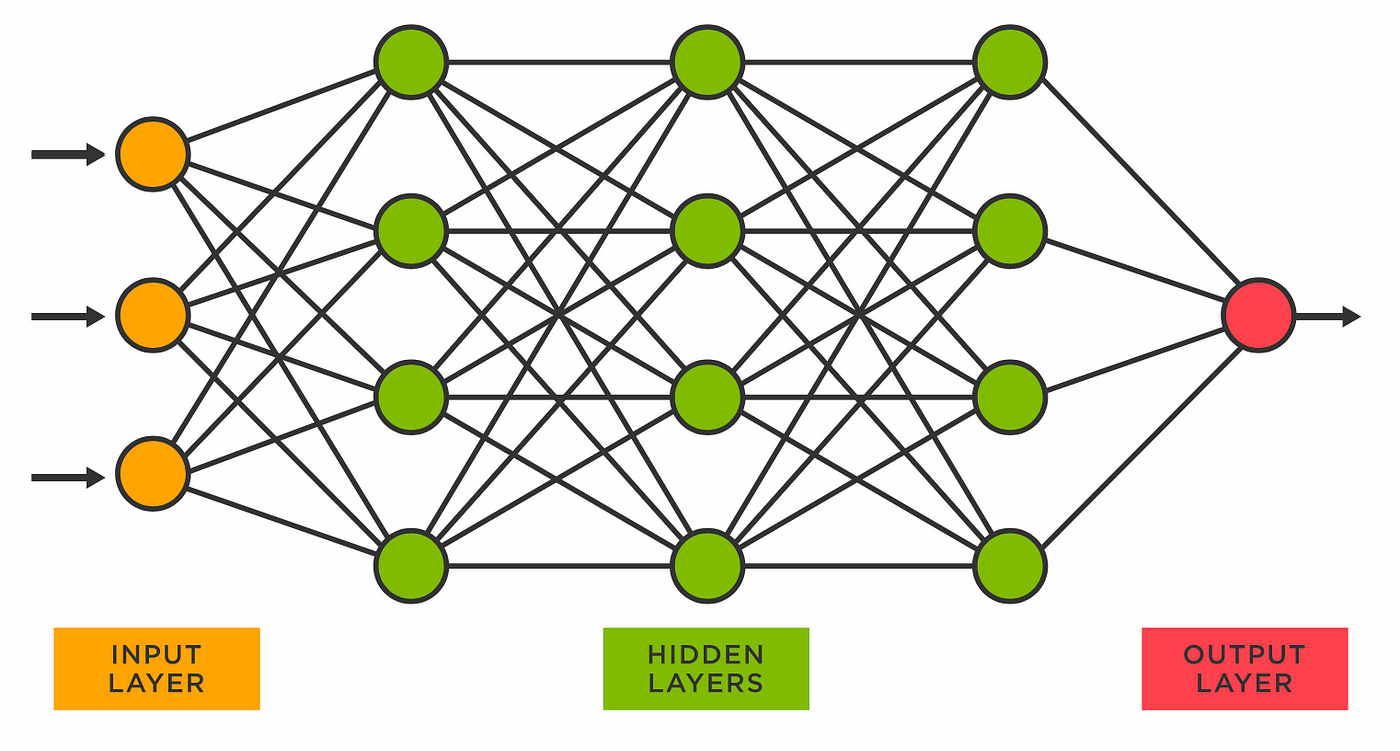
</div>

Basic functionality of a neuron:

<div>
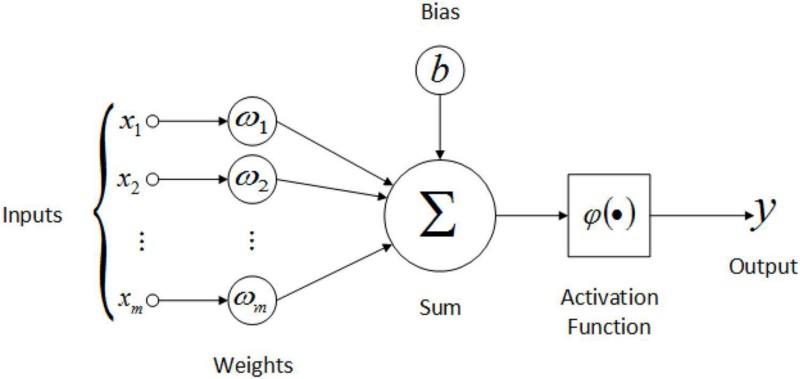
</div>

For more information on Artificial Neural Networks (ANNs) see the resources section below.

In the Machine Learning community a set of widely used frameworks established for generation of Neural Networks. Among them are:
- PyTorch
- Tensorflow (especially their Keras-Framework)
- scikit-learn

We will introduce those with a few examples.

## Architecture

Input -> Layers -> Output

Inspiration: https://towardsdatascience.com/math-neural-network-from-scratch-in-python-d6da9f29ce65

### Forward propagation: 
We can already emphasize one important point which is: the output of one layer is the input of the next one.

### Gradient Descent 
Basically, we want to change some parameter in the network (call it w) so that the total error E decreases.

### Backward propagation

# Fully Connected Layer 

Very simple, just two layers and every input neuron is connected to every output neuron 

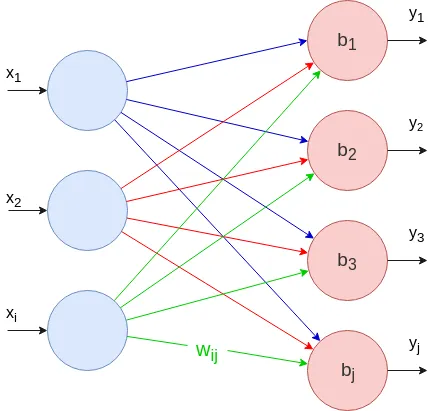!

In [ ]:
# Base class
class Layer:
    def __init__(self):
        self.input = None
        self.output = None

    # computes the output Y of a layer for a given input X
    def forward_propagation(self, input):
        raise NotImplementedError

    # computes dE/dX for a given dE/dY (and update parameters if any)
    def backward_propagation(self, output_error, learning_rate):
        raise NotImplementedError

In [ ]:
#from layer import Layer

# inherit from base class Layer
class FCLayer(Layer):
    # input_size = number of input neurons
    # output_size = number of output neurons
    def __init__(self, input_size, output_size):
        self.weights = np.random.rand(input_size, output_size) - 0.5
        self.bias = np.random.rand(1, output_size) - 0.5

    # returns output for a given input
    def forward_propagation(self, input_data):
        self.input = input_data
        self.output = np.dot(self.input, self.weights) + self.bias
        return self.output

    # computes dE/dW, dE/dB for a given output_error=dE/dY. Returns input_error=dE/dX.
    def backward_propagation(self, output_error, learning_rate):
        input_error = np.dot(output_error, self.weights.T)
        weights_error = np.dot(self.input.T, output_error)
        # dBias = output_error

        # update parameters
        self.weights -= learning_rate * weights_error
        self.bias -= learning_rate * output_error
        return input_error

## Activation Functions

This Part follows https://medium.com/@okanyenigun/building-a-neural-network-from-scratch-in-python-a-step-by-step-guide-8f8cab064c8a

### Sigmoid Function
Smooth S-shaped function, that maps the input between 0 and 1.

Sigmoid functions are ofte used as activation functions in neural networks.

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

plt.plot(np.linspace(-10, 10, num=51), sigmoid(np.linspace(-10, 10, num=51)))

plt.xlabel('X')
plt.ylabel('Activation')
plt.text(-9, 0.9, r'$\sigma(x)=\frac{1}{1+e^{-x}}$', fontsize=20)

plt.show()

In [ ]:
from scipy.special import expit

plt.plot(np.linspace(-10, 10, num=51), expit(np.linspace(-10, 10, num=51)))

plt.xlabel('X')
plt.ylabel('Activation')
plt.text(-9, 0.9, r'$\sigma(x)=\frac{1}{1+e^{-x}}$', fontsize=20)

plt.show()

### Tanh
The tanh (hyperbolic tangent) activation function is a mathematical function that maps the input to a value between -1 and 1, providing a smooth S-shaped curve centered around zero.

In [ ]:
def tanh(x):
    return np.tanh(x)

plt.plot(np.linspace(-10, 10, num=51), tanh(np.linspace(-10, 10, num=51)))
plt.xlabel('X')
plt.ylabel('Activation')

### Rectified Linear Unit (ReLU)

The ReLU (Rectified Linear Unit) activation function is a mathematical function that returns the input if it is positive, and zero otherwise, providing a piecewise linear output.

In [ ]:
def relu(x):
    return np.maximum(0, x)

plt.plot(np.linspace(-10, 10, num=51), relu(np.linspace(-10, 10, num=51)))
plt.xlabel('X')
plt.ylabel('Activation')

### Leaky ReLU

The Leaky ReLU activation function is a variation of the ReLU function that allows a small, non-zero output for negative input values, preventing complete suppression of information.

In [ ]:
def leaky_relu(x, alpha=0.1):
    return np.maximum(alpha*x, x)

plt.plot(np.linspace(-10, 10, num=51), leaky_relu(np.linspace(-10, 10, num=51)))
plt.xlabel('X')
plt.ylabel('Activation')

### Softmax
The softmax activation function is a mathematical function commonly used in multiclass classification tasks to convert a vector of real values into a probability distribution over multiple classes.

In [ ]:
def softmax(x):
    exp_scores = np.exp(x)
    return exp_scores / np.sum(exp_scores)

plt.plot(np.linspace(-10, 10, num=51), softmax(np.linspace(-10, 10, num=51)))
plt.xlabel('X')
plt.ylabel('Activation')

## Gaussian error linear unit (GELU)

In [ ]:
def gelu(x):
    gelu = 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))
    return gelu

plt.plot(np.linspace(-10, 10, num=51), gelu(np.linspace(-10, 10, num=51)))
plt.xlabel('X')
plt.ylabel('Activation')